[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/ofermend/hands-on-rag/blob/main/chapter2/embedding.ipynb)

# Chapter 2: Sentence Embeddings and Similarity

This notebook demonstrates how to generate sentence embeddings using SentenceTransformers and compute cosine similarity between sentences.

**What you'll learn:**
- Generate sentence embeddings using the all-MiniLM-L6-v2 model
- Compute and visualize cosine similarity matrices
- Understand how semantic meaning is captured in embedding dimensions

**Prerequisites:** `pip install sentence-transformers matplotlib`

## Generate Embeddings

We use the all-MiniLM-L6-v2 model (via the SentenceTransformer library) to convert short sentences into 384-dimensional vectors that capture their semantic meaning.

In [1]:
from sentence_transformers import SentenceTransformer
import random 
import matplotlib.pyplot as plt

# Load the pre-trained Sentence Transformer model
model = SentenceTransformer('all-MiniLM-L6-v2')

In [2]:
# List of sentences to encode
sentences = [
    "I am a happy person.",
    "I am a joyful person.",
    "I am a pessimistic person.",
    "I am not an optimistic person."
]

# Generate embeddings for the sentences
embeddings = model.encode(sentences)

In [3]:
# Let's take a look at the embeddings

print (embeddings.shape)
print (embeddings[:, :5]) # only first 5 dimension due to space constraints


(4, 384)
[[ 0.00464726  0.06651061  0.01479143 -0.02955708 -0.03556158]
 [ 0.03454587  0.05649178  0.00730664 -0.07299497 -0.06663912]
 [ 0.06152034  0.05317362  0.0178834   0.03482828 -0.03031248]
 [ 0.02471705  0.02527624 -0.00175564  0.0208724  -0.03713482]]


## Cosine Similarity

By computing pairwise cosine similarity we can see how closely the model considers each sentence pair — near-synonyms should score high, opposites should score low.

In [4]:
# compute the cosine similarity between the embeddings
similarity_matrix = model.similarity(embeddings, embeddings)
print (similarity_matrix)

tensor([[1.0000, 0.8151, 0.3864, 0.5210],
        [0.8151, 1.0000, 0.3383, 0.4128],
        [0.3864, 0.3383, 1.0000, 0.7047],
        [0.5210, 0.4128, 0.7047, 1.0000]])


> **Note:** The similarity scores confirm that embeddings capture semantic meaning. "Happy" and "joyful" score 0.82 (near-synonyms), while "happy" and "pessimistic" score only 0.39 (opposite sentiment). Notice that "not optimistic" scores 0.70 with "pessimistic" — the model partially understands negation but doesn't treat it as a perfect synonym.

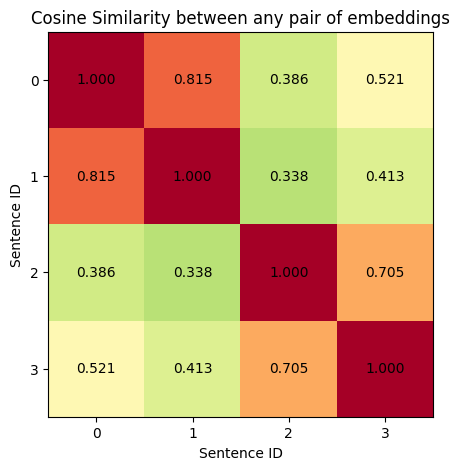

In [5]:
# visualize the similarity matrix using heatmap 

plt.figure(figsize=(5, 5))
plt.imshow(similarity_matrix, cmap='RdYlGn_r', interpolation='nearest', vmin=0, vmax=1)
plt.title('Cosine Similarity between any pair of embeddings')
plt.xlabel('Sentence ID')
plt.ylabel('Sentence ID')
plt.xticks([0, 1, 2, 3])
plt.yticks([0, 1, 2, 3])

# Add text annotations
for i in range(len(similarity_matrix)):
    for j in range(len(similarity_matrix)):
        plt.text(j, i, f'{similarity_matrix[i][j]:.3f}', 
                ha='center', va='center', color='black')

plt.show()

## Similarity on Random Dimensions

To show that semantic information is spread across the full embedding vector rather than concentrated in a few dimensions, we compute similarity using only a random slice of the 384 dimensions.

In [6]:
# compute the cosine similarity between the embeddings between two random semantic dimensions

# generate two random integers between 0 and 384
rand1 = random.randint(0, 384)
rand2 = random.randint(0, 384)

if rand1 > rand2:
    rand1, rand2 = rand2, rand1

print (f"Using semantic dimensions {rand1} to {rand2}")

similarity_matrix = model.similarity(embeddings[:, rand1:rand2], embeddings[:, rand1:rand2])
print (similarity_matrix)

Using semantic dimensions 62 to 216
tensor([[1.0000, 0.7927, 0.3904, 0.5860],
        [0.7927, 1.0000, 0.3108, 0.4530],
        [0.3904, 0.3108, 1.0000, 0.6854],
        [0.5860, 0.4530, 0.6854, 1.0000]])
